In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

from modtran_analysis.tools import utils

# Loading in the data file to read
from importlib import resources

LOCAL_DATA_PATH = resources.files("modtran_analysis") / "data"
DATA_FILE_PATH = LOCAL_DATA_PATH / "FV3_Modtran6_IO_v3_scene_1.nc"
ds_v2 = xr.open_dataset(DATA_FILE_PATH)
wavelength_v2_sw = ds_v2['wavelength_sw']
wavelength_v2_lw = ds_v2['wavelength_lw']
ERBE_RAA_v2 = ds_v2['ERBE_RAA']
ERBE_SZA_v2 = ds_v2['ERBE_SZA']
ERBE_VZA_v2 = ds_v2['ERBE_VZA']
CERES_TRMM_RAA_v2 = ds_v2['CERES_TRMM_RAA']
CERES_TRMM_SZA_v2 = ds_v2['CERES_TRMM_SZA']
CERES_TRMM_VZA_v2 = ds_v2['CERES_TRMM_VZA']
spectral_radiance_toa_sw_ERBE_v2 = ds_v2['MODTRAN6_SPECTRAL_RADIANCE_TOA_SW_WVL_ERBE']
spectral_radiance_toa_lw_ERBE_v2 = ds_v2['MODTRAN6_SPECTRAL_RADIANCE_TOA_LW_WVL_ERBE']
spectral_radiance_toa_sw_CERES_TRMM_v2 = ds_v2['MODTRAN6_SPECTRAL_RADIANCE_TOA_SW_WVL_CERES_TRMM']
spectral_radiance_toa_lw_CERES_TRMM_v2 = ds_v2['MODTRAN6_SPECTRAL_RADIANCE_TOA_LW_WVL_CERES_TRMM']
IGBP_Land_Type_v2 = ds_v2['IGBP_Type']

In [ ]:
spectral_radiance_toa_sw_ERBE_v2.shape

In [ ]:
wavelength_v2 = xr.DataArray(np.append(wavelength_v2_sw, wavelength_v2_lw))
spectral_radiance_toa_ERBE_v2 = xr.DataArray(np.append(spectral_radiance_toa_sw_ERBE_v2[0][0][0][:], spectral_radiance_toa_lw_ERBE_v2[0][0][0][:]))

ERBE_SZA_v2[0].dtype
print(ERBE_SZA_v2.values[0])

In [ ]:
def sw_lw_spectra(spectral_radiance_toa_sw: xr.DataArray = None, spectral_radiance_toa_lw: xr.DataArray = None, RAA_bin: float = None, VZA_bin: float = None, SZA_bin: float = None):
    '''
    Combines the spectral radiance for shortwave wavelengths and longwave wavelengths.

    Using the arrays of shortwave radiance and longwave radiance this function creates a longer array with the two arrays appended together.

    Parameters
    -----------
    spectral_radiance_toa_sw_ERBE_v2: xr.DataArray


    spectral_radiance_toa_lw_ERBE_v2: xr.DataArray


    RAA: str


    VZA: str


    SZA: str


    Returns
    -------


    '''
    spectral_radiance_toa = np.append(spectral_radiance_toa_sw[VZA_bin][SZA_bin][RAA_bin][:], spectral_radiance_toa_lw[VZA_bin][SZA_bin][RAA_bin][:])
    return xr.DataArray(spectral_radiance_toa)

print(sw_lw_spectra(spectral_radiance_toa_sw_ERBE_v2,spectral_radiance_toa_lw_ERBE_v2, RAA_bin=0, VZA_bin=0, SZA_bin=0).dtype)



from visualization import plotting

plt.figure(figsize=(10,6))
plotting.plot_single_spectrum(wavelength_v2, spectrum_data=utils.unit_conversion(sw_lw_spectra(spectral_radiance_toa_sw_ERBE_v2,spectral_radiance_toa_lw_ERBE_v2, RAA_bin=0, VZA_bin=0, SZA_bin=0)),
                              title=f'MODTRAN6 Spectrally-Resolved Top-of-Atmosphere Radiance in wavelength units at ERBE ADM angles\n(at 2.5 nm 250-5000 nm)',
                              RAA=f'{ERBE_RAA_v2.values[0]}', SZA=f'{ERBE_SZA_v2.values[0]}', VZA=f'{ERBE_VZA_v2.values[0]}',
                              scene=f'{IGBP_Land_Type_v2.values}', data_version='V2')
plt.show()

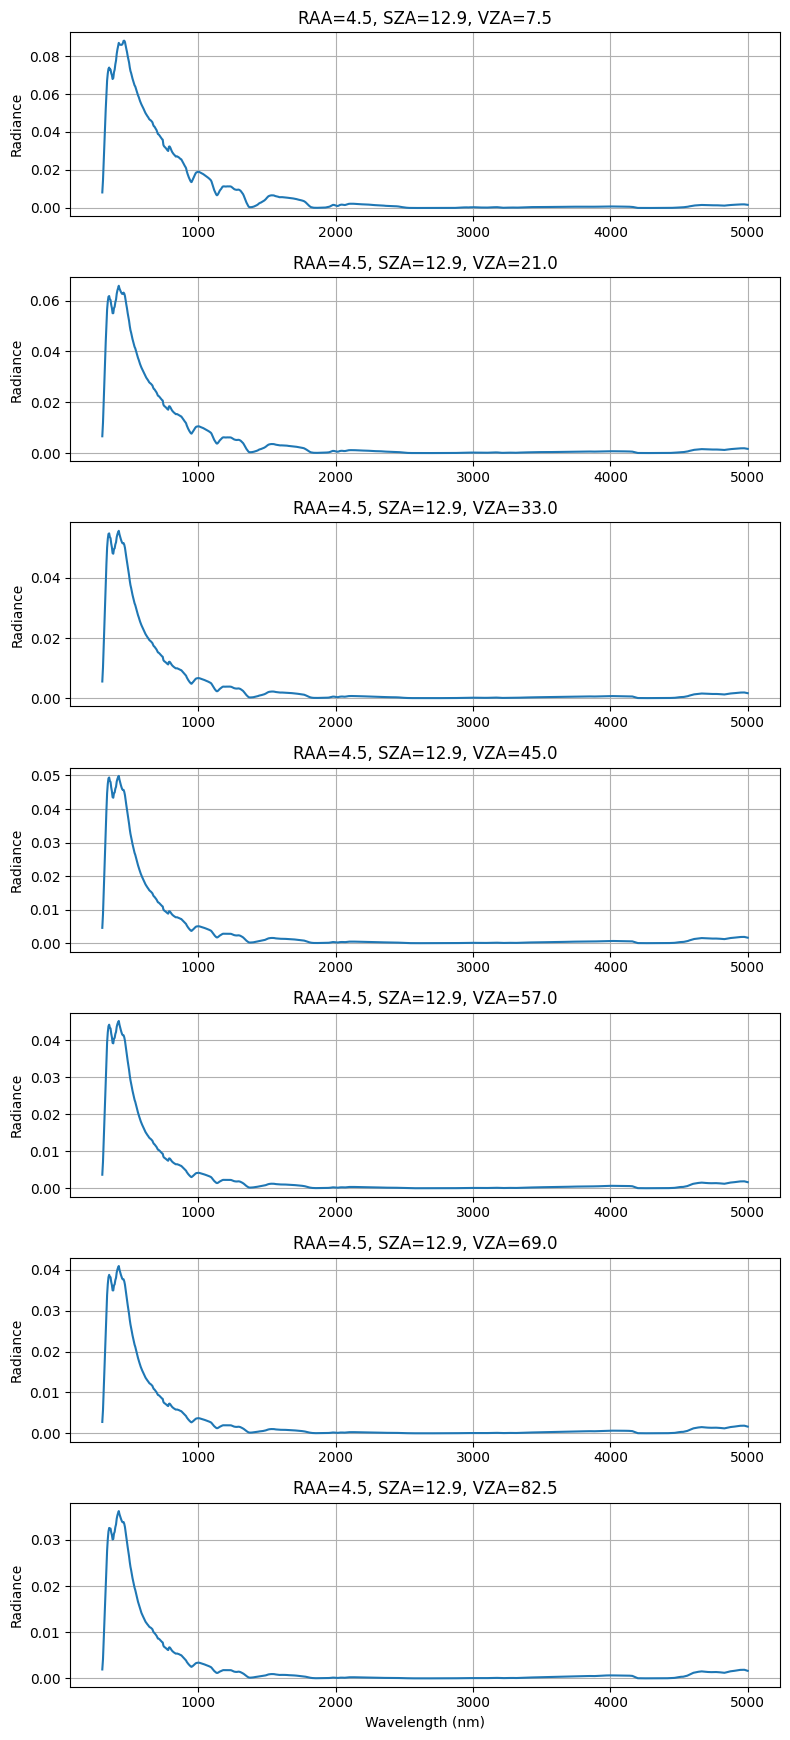

In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from modtran_analysis.tools import utils
import visualization.plotting as plotting
from importlib import resources


LOCAL_DATA_PATH = resources.files("modtran_analysis") / "data"
DATA_FILE_PATH = LOCAL_DATA_PATH / "FV3_Modtran6_IO_v0_scene_1(1).nc"

ds_v0 = xr.open_dataset(DATA_FILE_PATH)

# Extracting the specific data we want to plot

wavelength_v0 = ds_v0['wavelength']
RAA_v0 = ds_v0['RAA']
SZA_v0 = ds_v0['SZA']
VZA_v0 = ds_v0['VZA']

spectral_radiance_toa_v0 = ds_v0['MODTRAN6_SPECTRAL_RADIANCE_TOA']

# plotting.plot_single_spectrum(wavelength_v0, spectrum_data=utils.unit_conversion(spectral_radiance_toa_v0[0][0][0][:]),
#                               title='MODTRAN6 calculated Spectrally-Resolved TOA Radiance \n(at 5 nm 300-5000 nm)',
#                               RAA=f'{RAA_v0.values[0]}', SZA=f'{SZA_v0.values[0]}', VZA=f'{VZA_v0.values[0]}', data_version='V0')


# ---- parameters ----
RAA_fixed = RAA_v0.values[0]
SZA_fixed = SZA_v0.values[0]
VZA_list = VZA_v0.values  # loop over these

# ---- create subplots ----
n = len(VZA_list)
fig, axes = plt.subplots(n, 1, figsize=(8, 2.5*n), sharex=False)

if n == 1:
    axes = [axes]   # make iterable if only one subplot


def get_radiance(vza_index):
    wavelength = wavelength_v0.values
    radiance = utils.unit_conversion(spectral_radiance_toa_v0[0, 0, vza_index, :])
    return wavelength, radiance

for ax, (i, vza) in zip(axes, enumerate(VZA_list)):
    wavelength, radiance = get_radiance(i)
    ax.plot(wavelength, radiance)
    ax.set_title(f"RAA={RAA_fixed}, SZA={SZA_fixed}, VZA={vza}")
    ax.set_ylabel("Radiance")
    ax.grid(True)

axes[-1].set_xlabel("Wavelength (nm)")
plt.tight_layout()
plt.show()


In [11]:
for ax, vza in zip(axes, VZA_list):
    print(type(vza), vza)
    break

<class 'numpy.float64'> 7.5


In [15]:
print(radiance)

TypeError: 'NoneType' object is not subscriptable

None


TypeError: Expected 'float' or DataArray for radiance, got NoneType instead.

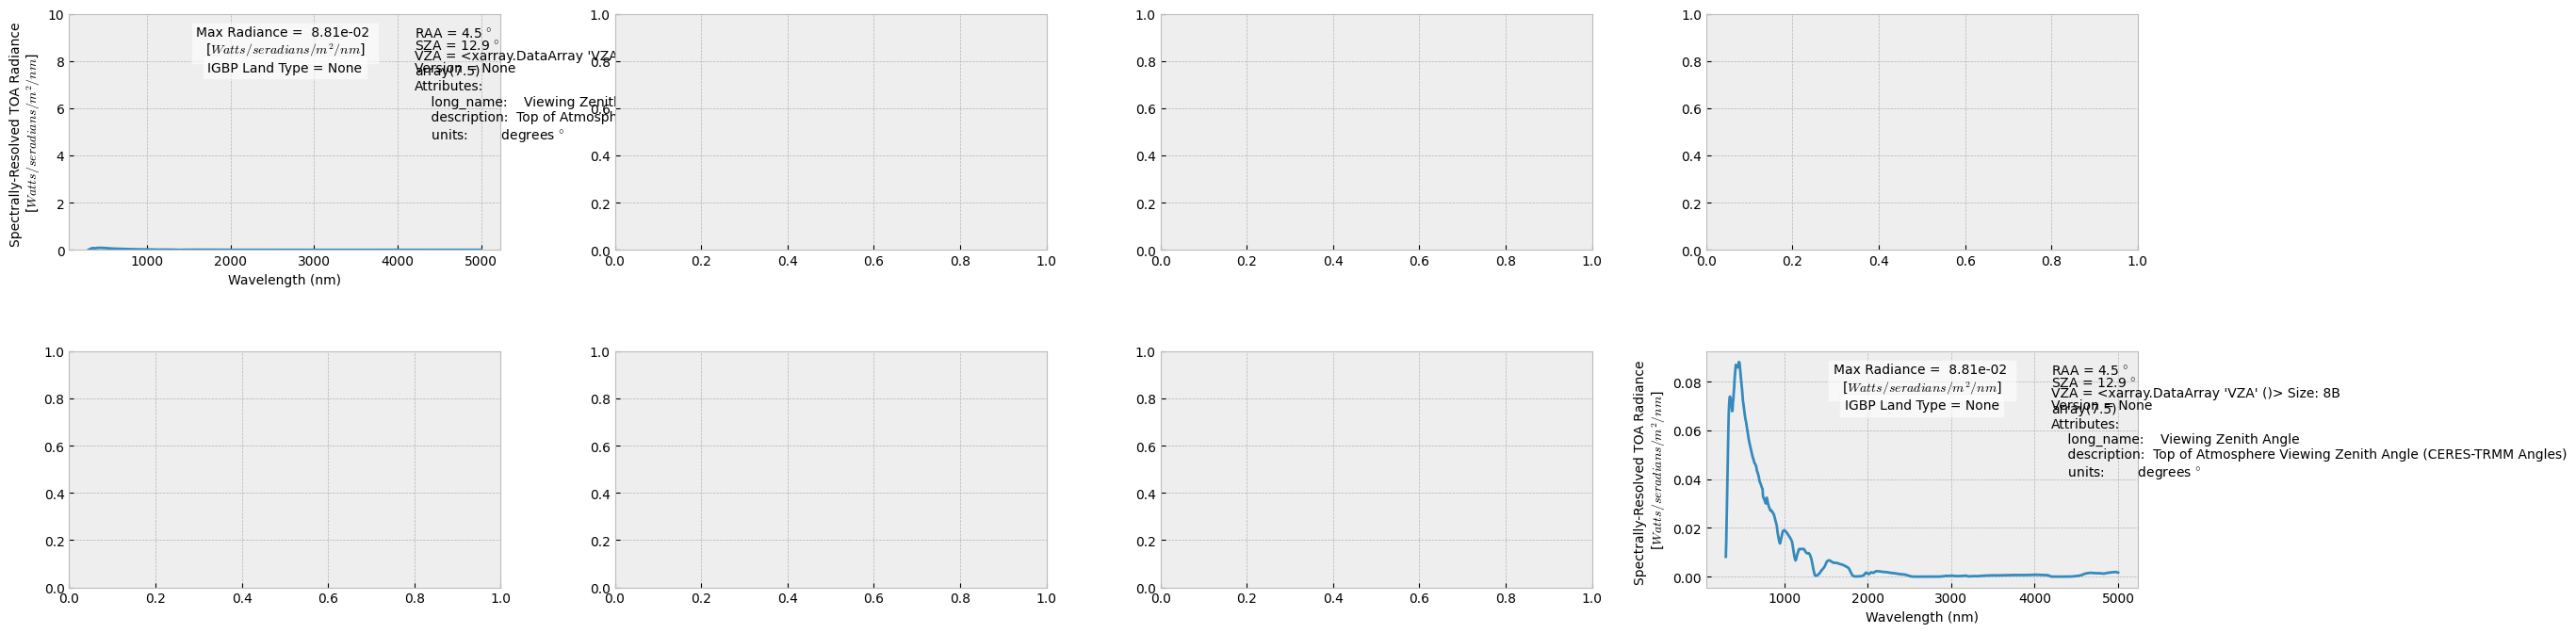

In [32]:
def plot_single_spectrum(...):
    spectrum_data = utils.unit_conversion(spectrum_data)

    fig, ax = plt.subplots()
    ax.plot(wavelength_data, spectrum_data)

    ax.set_ylabel('Spectrally-Resolved TOA Radiance \n[$Watts/seradians/m^2/nm$]', fontsize=10)
    ax.set_xlabel('Wavelength (nm)', fontsize=10)
    ax.set_title(title, fontsize=10)

    ax.text(.8, .8, f"Version = {data_version}", transform=ax.transAxes,
            ha='left', va='top', fontsize=10)

    if RAA is not None:
        ax.text(.8, .95, f"RAA = {RAA} $\degree$", transform=ax.transAxes,
                ha='left', va='top', fontsize=10)

    if SZA is not None:
        ax.text(.8, .9, f"SZA = {SZA} $\degree$", transform=ax.transAxes,
                ha='left', va='top', fontsize=10)

    if VZA is not None:
        ax.text(.8, .85, f"VZA = {VZA} $\degree$", transform=ax.transAxes,
                ha='left', va='top', fontsize=10)

    ax.text(.5, .95,
            f"Max Radiance = {spectrum_data.max(): .2e} \n[$Watts/seradians/m^2/nm$]",
            transform=ax.transAxes,
            ha='center', va='top', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.6))

    ax.text(.5, .80, f"IGBP Land Type = {scene}",
            transform=ax.transAxes, ha='center', va='top', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.6))

    return fig, ax



RAA_fixed = RAA_v0.values[0]
SZA_fixed = SZA_v0.values[0]

plt.style.use('bmh')

# Create a figure with 8 subplots (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(24, 8))
fig.tight_layout(pad=6.0)

# Flatten the 2D axes array for easy iteration
axes = axes.flatten()
print(plotting.plot_single_spectrum(wavelength_v0, spectrum_data=spectral_radiance_toa_v0[0][0][0][:], RAA=RAA_fixed, SZA=SZA_fixed, VZA=VZA_v0[0]))

# Loop through VZA and plot on corresponding subplot
for i in range(len(VZA_v0)):
    ax = axes[i]
    plt.sca(ax)  # Set current axis
    ax.set_ylim(0, 10)
    utils.unit_conversion(plotting.plot_single_spectrum(wavelength_v0, spectrum_data=spectral_radiance_toa_v0[i][0][0][:], RAA=RAA_fixed, SZA=SZA_fixed, VZA=VZA_v0[i]))

    plt.suptitle(
        f'All the VZA angles for RAA = {RAA_fixed} $\degree$ and SZA = {SZA_fixed} $\degree$',
        fontsize=14)
    plt.show()

print(plotting.plot_single_spectrum(wavelength_v0, spectrum_data=spectral_radiance_toa_v0[i][0][0][:], RAA=RAA_fixed, SZA=SZA_fixed, VZA=VZA_v0[i]))


# Make a bajillion graphs

# for i in range(len(VZA)):
#     for j in range(len(SZA)):
#         RAA_graphs(i,j)

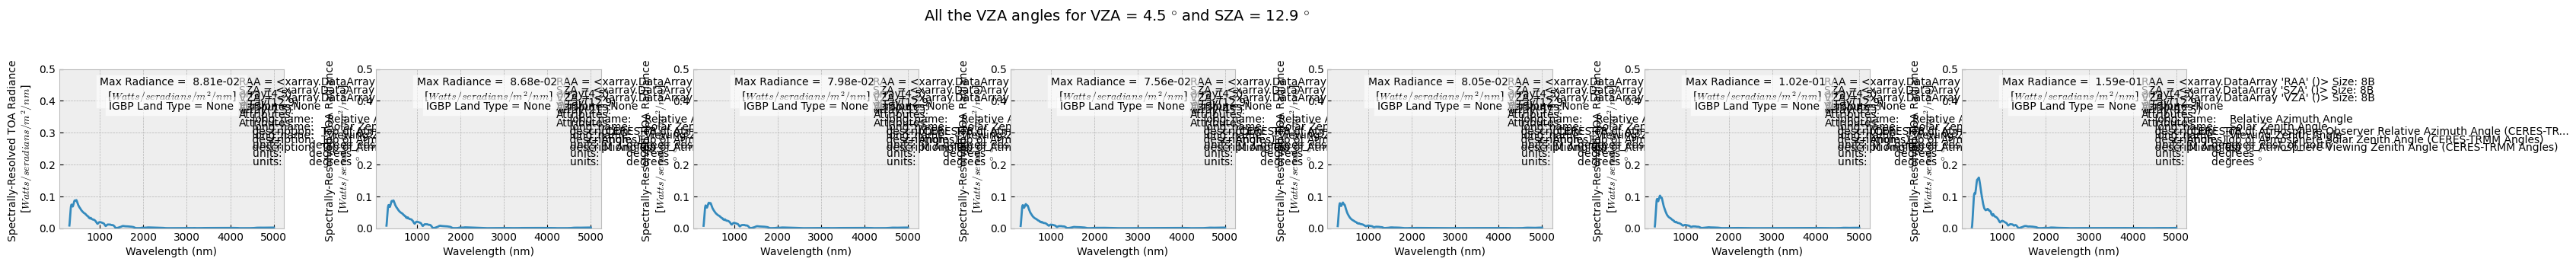

In [48]:
plt.style.use('bmh')
import math

# Create a figure with 8 subplots (2 rows x 4 columns)
fig, axes = plt.subplots(1, len(VZA_v0.values), figsize=(30, 4))
fig.tight_layout(pad=6.0)


# Flatten the 2D axes array for easy iteration
axes = axes.flatten()

# Loop through RAA and plot on corresponding subplot
for i in range(len(VZA_v0)):
    ax = axes[i]
    plt.sca(ax)  # Set current axis
    ax.set_ylim(0, .5)
    plotting.plot_single_spectrum(wavelength_data=wavelength_v0, spectrum_data= spectral_radiance_toa_v0[i][0][0], RAA=RAA_v0[0], SZA=SZA_v0[0], VZA=VZA_v0[i])

plt.suptitle(f'All the VZA angles for VZA = {RAA_v0.values[0]} $\degree$ and SZA = {SZA_v0.values[0]} $\degree$', fontsize=14)
plt.show()

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from modtran_analysis.tools import utils

# Loading in the data file to read
from importlib import resources

LOCAL_DATA_PATH = resources.files("modtran_analysis") / "data"
DATA_FILE_PATH = LOCAL_DATA_PATH / "FV3_Modtran6_IO_v0_scene_1(1).nc"

ds_v0 = xr.open_dataset(DATA_FILE_PATH)

# Extracting the specific data we want to plot

wavelength_v0 = ds_v0['wavelength']
RAA_v0 = ds_v0['RAA']
SZA_v0 = ds_v0['SZA']
VZA_v0 = ds_v0['VZA']

spectral_radiance_toa_v0 = ds_v0['MODTRAN6_SPECTRAL_RADIANCE_TOA']

# Plotting Viewing geometries V0
from visualization import plotting
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
plotting.plot_viewing_geometry(RAA_v0, 'RAA', 'Unfiltering', data_version='V0')

plt.subplot(1,3,2)
plotting.plot_viewing_geometry(SZA_v0, 'SZA', 'Unfiltering', data_version='V0')

plt.subplot(1,3,3)
plotting.plot_viewing_geometry(VZA_v0, 'VZA', 'Unfiltering', data_version='V0')

plt.show()

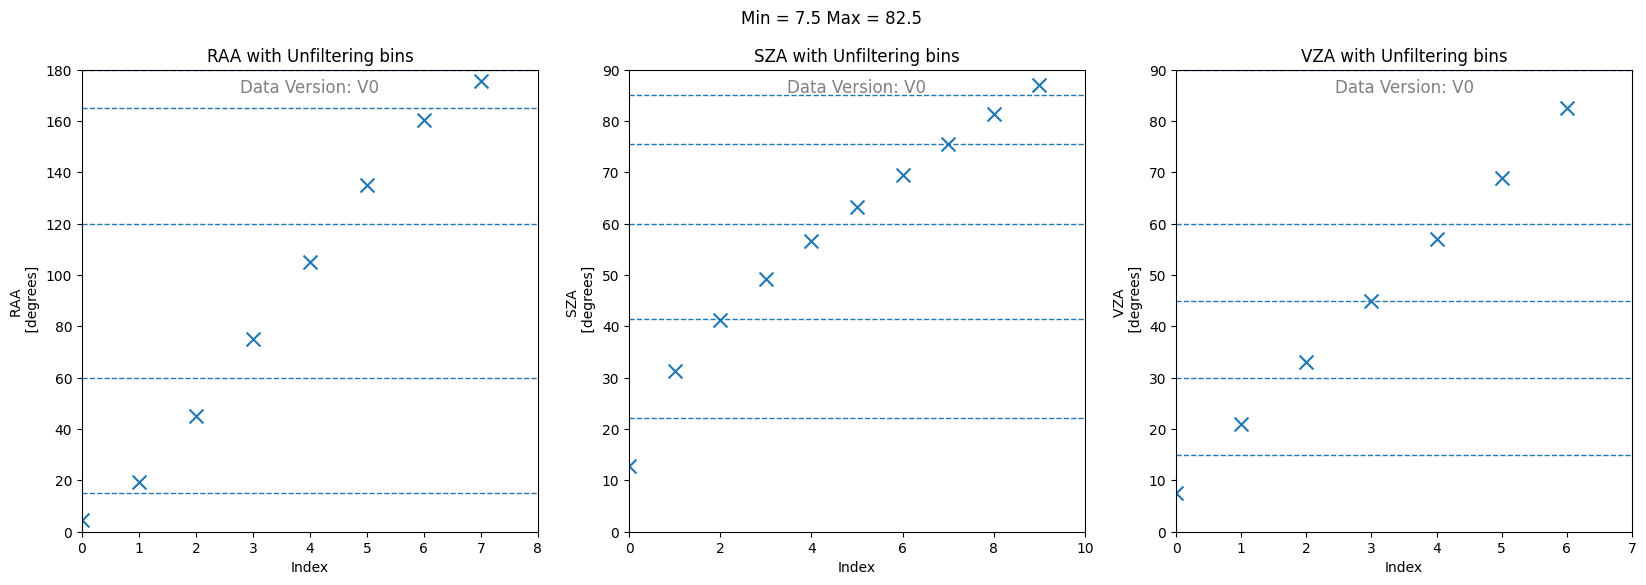

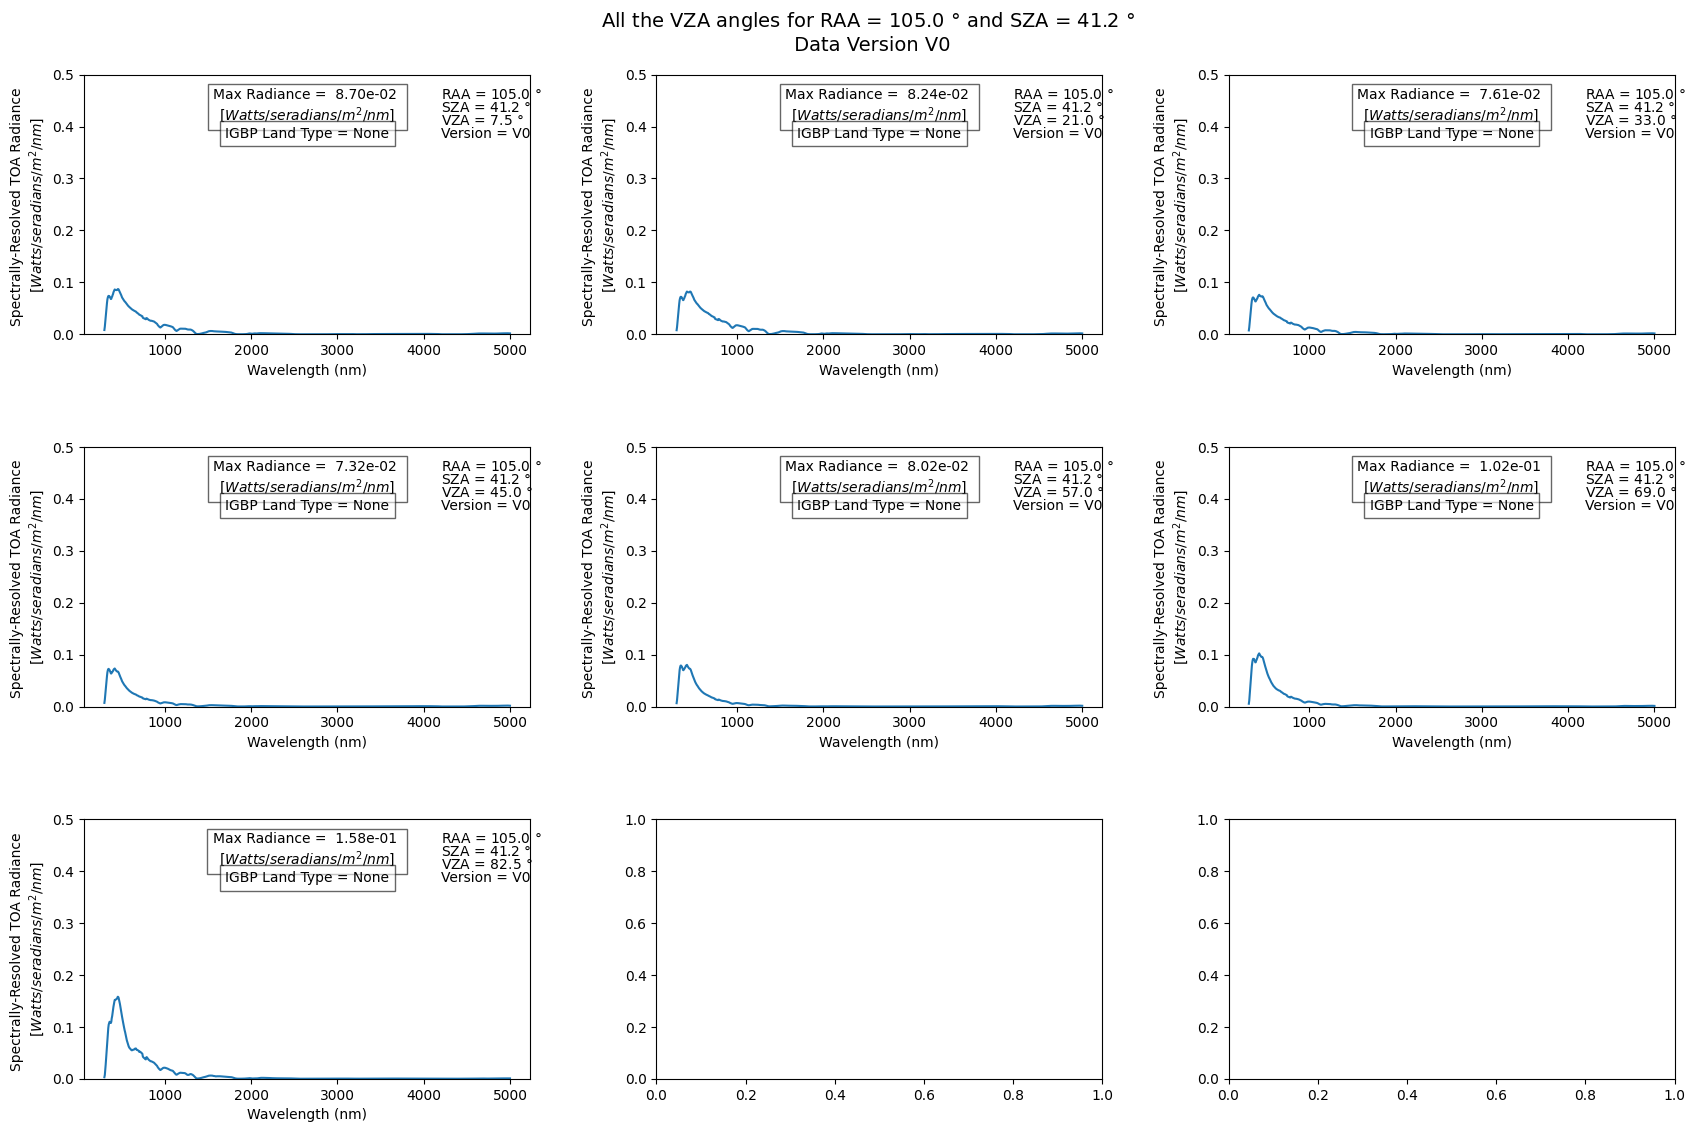

In [12]:
import math

n_vza = len(VZA_v0.values)
ncols = 3
nrows = math.ceil(n_vza / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
fig.tight_layout(pad=6.0)
# Flatten the 2D axes array for easy iteration
axes = axes.flatten()
# Loop through VZA and plot on corresponding subplot
for i in range(len(VZA_v0)):
    ax = axes[i]
    plt.sca(ax)  # Set current axis
    ax.set_ylim(0, .5)
    plotting.plot_single_spectrum(wavelength_data=wavelength_v0, spectrum_data= spectral_radiance_toa_v0[i][2][4],
                                  RAA=f'{RAA_v0.values[4]}', SZA=f'{SZA_v0.values[2]}', VZA=f'{VZA_v0.values[i]}', data_version='V0')

plt.suptitle(f'All the VZA angles for RAA = {RAA_v0.values[4]} $\degree$ and SZA = {SZA_v0.values[2]} $\degree$ \n Data Version V0', fontsize=14)
plt.show()
# plt.savefig("/Users/kese6848/Desktop/Figures/Viewing-Geometry-v0.jpeg")
# plt.close()

In [27]:
plt.figure(figsize=(15,15))
for i in range(len(VZA_v0)):
    vza_legend = VZA_v0.values[i]
    print(vza_legend)
    plotting.plot_single_spectrum(wavelength_data=wavelength_v0, spectrum_data= spectral_radiance_toa_v0[i][2][4],
                                  SZA=f'{SZA_v0.values[2]}', RAA=f'{RAA_v0.values[4]}', VZA=f'{vza_legend}', data_version='V0',label=f'{vza_legend}')


7.5


TypeError: plot_single_spectrum() got an unexpected keyword argument 'label'

<Figure size 1500x1500 with 0 Axes>

In [26]:
colors = plt.cm.viridis(np.linspace(0, 1, len(VZA_v0)))

plt.figure(figsize=(15, 15))

for i, (vza, color) in enumerate(zip(VZA_v0.values, colors)):
    plotting.plot_single_spectrum(
        wavelength_data=wavelength_v0,
        spectrum_data=spectral_radiance_toa_v0[i][2][4],
        label=f'VZA = {vza}°'
    )
    plt.gca().lines[-1].set_color(color)

plt.legend(title="VZA")
plt.show()


TypeError: plot_single_spectrum() got an unexpected keyword argument 'label'

<Figure size 1500x1500 with 0 Axes>

In [28]:
plt.figure(figsize=(15,15))
for i in range(len(VZA_v0)):
    vza_legend = VZA_v0.values[i]
    plot_single_spectrum(wavelength_data=wavelength_v0, spectrum_data= spectral_radiance_toa_v0[i][2][4],
                                  SZA=f'{SZA_v0.values[2]}', RAA=f'{RAA_v0.values[4]}', VZA=f'{vza_legend}', data_version='V0',label=f'{vza_legend}')

7.5


TypeError: plot_single_spectrum() got an unexpected keyword argument 'label'

<Figure size 1500x1500 with 0 Axes>

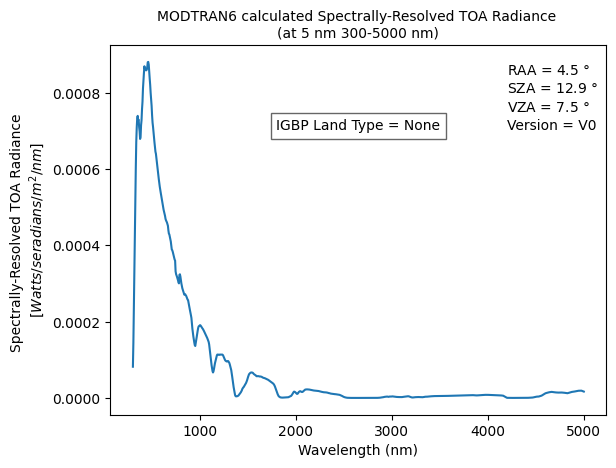

In [30]:
def plot_single_spectrum(wavelength_data: xr.DataArray, spectrum_data: xr.DataArray = None, title: str = None,
                         RAA: str = None, SZA: str = None, VZA: str = None, scene: str = None, data_version: str = None,
                         label: str = None, print_max_radiance=True):
    '''
    Creates a plot of the spectral radiance data over the wavelength range

    Providing the wavelength, you are able to add the spectral data for different viewing geometries of the
    MODTRAN data. You are also given the option of adding a plot title, and the values for the different viewing
    geometries.

    Parameters
    ----------

    wavelength_data: xr.DataArray
        this is the Xarray DataArray of the actual wavelength data that we are integrating values over

    spectrum_data: xr.DataArray
        This is the Xarray DataArray of the actual spectral radiance data we are observing from various
        viewing geometries
        This is expected in the units of [micro-W SR-1 CM-2 / NM]
            Example- spectrum_data=spectrum_data[VZA_angle][SZA_angle][RAA_angle][:]

    title: str
        this is the title of the plot you wish to display

    RAA: str
        this is the RAA value that we are plotting in spectrum_data. This will be displayed as a
        text box on the plot

    SZA: str
        this is the SZA value that we are plotting in spectrum_data. This will be displayed as a
        text box on the plot

    VZA: str
        this is the VZA value that we are plotting in spectrum_data. This will be displayed as a
        text box on the plot

    scene: str
        this is the IGBP scene that we are plotting in spectrum_data. This will be displayed as a
        text box on the plot

    data_version: str
        this is the data version that we are plotting. This will be displayed as a text box on the plot

    label: str
        optional label for the plot
    Returns
    -------

    A spectral plot for a given viewing geometries for MODTRAN data
    '''
    spectrum_data= utils.unit_conversion(spectrum_data)
    plt.plot(wavelength_data, spectrum_data, label=label)
    plt.ylabel('Spectrally-Resolved TOA Radiance \n[$Watts/seradians/m^2/nm$]', fontsize=10)
    plt.xlabel('Wavelength (nm)', fontsize=10)
    plt.title(title, fontsize=10)
    plt.text(.8, .8, f"Version = {data_version}", transform=plt.gca().transAxes,
             ha='left', va='top', fontsize=10)
    if RAA is not None:
        plt.text(.8, .95 , f"RAA = {RAA} $\degree$", transform=plt.gca().transAxes,
            ha= 'left', va= 'top', fontsize=10)
    if SZA is not None:
        plt.text(.8, .9 , f"SZA = {SZA} $\degree$", transform=plt.gca().transAxes,
            ha= 'left', va= 'top', fontsize=10)
    if VZA is not None:
        plt.text(.8, .85 , f"VZA = {VZA} $\degree$", transform=plt.gca().transAxes,
            ha= 'left', va= 'top', fontsize=10)
    #TODO I am not the most content with what this is doing so I need to think about a way to make it nicer
    if print_max_radiance:
        plt.text(.5, .95 , f"Max Radiance = {spectrum_data.max(): .2f} \n[$Watts/seradians/m^2/nm$]", transform=plt.gca().transAxes,
            ha= 'center', va= 'top', fontsize=10, bbox=dict(facecolor='white', alpha=0.6))
    plt.text(.5, .80, f"IGBP Land Type = {scene}", transform=plt.gca().transAxes,ha= 'center',
             va= 'top', fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

# Compute global max across all VZAs
global_max_radiance = max(
    utils.unit_conversion(spectral_radiance_toa_v0[i][2][4]).max().item()
    for i in range(len(VZA_v0))
)

plt.figure(figsize=(15,15))
for i in range(len(VZA_v0)):
    vza_legend = VZA_v0.values[i]
    plot_single_spectrum(wavelength_data=wavelength_v0, spectrum_data= spectral_radiance_toa_v0[i][2][4],
                                  SZA=f'{SZA_v0.values[2]}', RAA=f'{RAA_v0.values[4]}', VZA=f'{vza_legend}', data_version='V0',label=f'{vza_legend}')

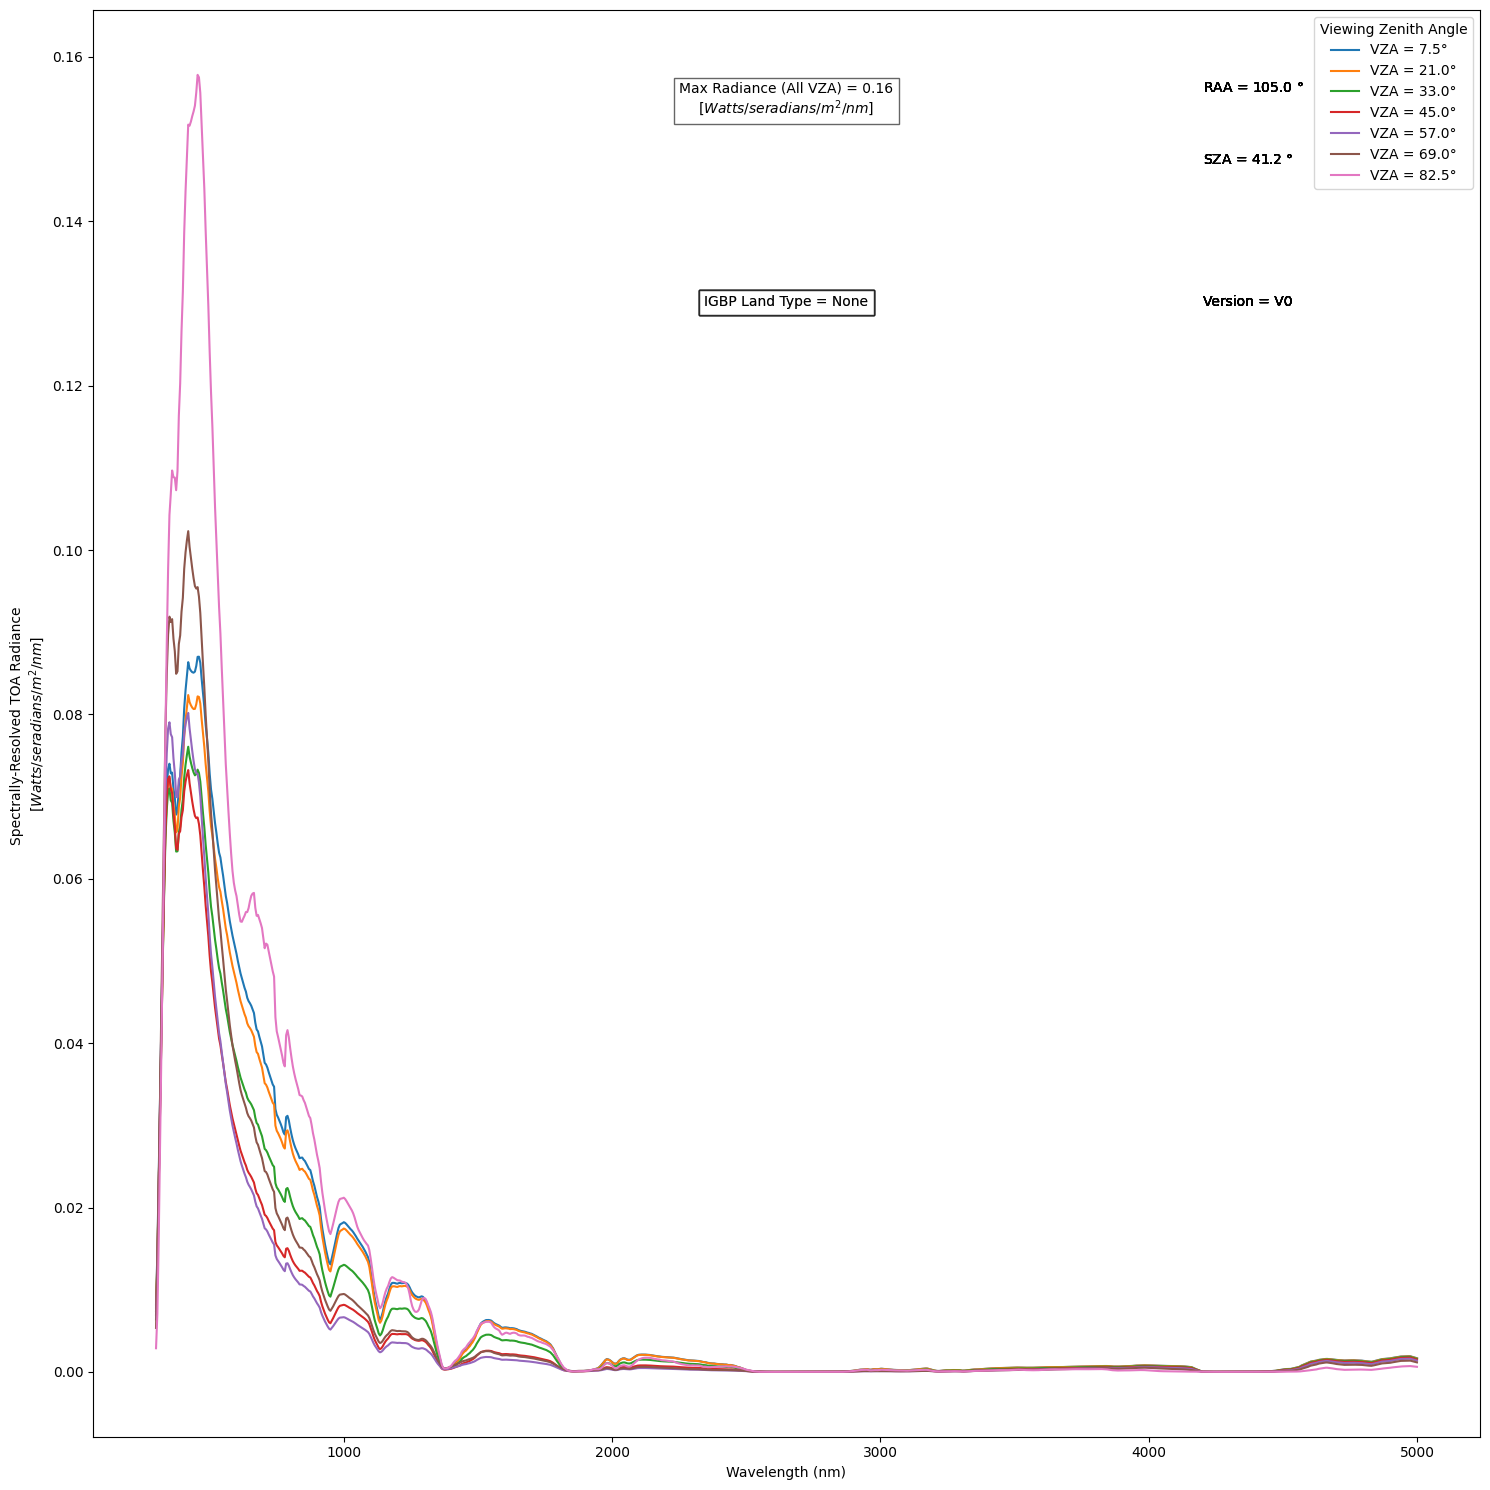

In [32]:
# ---- Compute absolute max radiance across all VZAs ----
global_max_radiance = max(
    utils.unit_conversion(spectral_radiance_toa_v0[i][2][4]).max().item()
    for i in range(len(VZA_v0))
)
plt.figure(figsize=(15, 12))

for i in range(len(VZA_v0)):
    vza_legend = VZA_v0.values[i]

    plot_single_spectrum(
        wavelength_data=wavelength_v0,
        spectrum_data=spectral_radiance_toa_v0[i][2][4],
        SZA=f'{SZA_v0.values[2]}',
        RAA=f'{RAA_v0.values[4]}',
        data_version='V0',
        label=f'VZA = {vza_legend}°',
        print_max_radiance=False
    )
plt.text(
    0.5, 0.95,
    f"Max Radiance (All VZA) = {global_max_radiance:.2f}\n"
    r"[$Watts/seradians/m^2/nm$]",
    transform=plt.gca().transAxes,
    ha='center',
    va='top',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.6)
)
plt.legend(title="Viewing Zenith Angle")
plt.tight_layout()
plt.show()


In [34]:
LOCAL_DATA_PATH = resources.files("modtran_analysis") / "data"
DATA_FILE_PATH = LOCAL_DATA_PATH / "FV3_Modtran6_IO_v3_scene_1.nc"
ds_v3 = xr.open_dataset(DATA_FILE_PATH)
wavelength_v3_sw = ds_v3['wavelength_sw']
wavelength_v3_lw = ds_v3['wavelength_lw']
ERBE_RAA_v3 = ds_v3['ERBE_RAA']
ERBE_SZA_v3 = ds_v3['ERBE_SZA']
ERBE_VZA_v3 = ds_v3['ERBE_VZA']
CERES_TRMM_RAA_v3 = ds_v3['CERES_TRMM_RAA']
CERES_TRMM_SZA_v3 = ds_v3['CERES_TRMM_SZA']
CERES_TRMM_VZA_v3 = ds_v3['CERES_TRMM_VZA']
spectral_radiance_toa_sw_ERBE_v3 = ds_v3['MODTRAN6_SPECTRAL_RADIANCE_TOA_SW_WVL_ERBE']
spectral_radiance_toa_lw_ERBE_v3 = ds_v3['MODTRAN6_SPECTRAL_RADIANCE_TOA_LW_WVL_ERBE']
spectral_radiance_toa_sw_CERES_TRMM_v3 = ds_v3['MODTRAN6_SPECTRAL_RADIANCE_TOA_SW_WVL_CERES_TRMM']
spectral_radiance_toa_lw_CERES_TRMM_v3 = ds_v3['MODTRAN6_SPECTRAL_RADIANCE_TOA_LW_WVL_CERES_TRMM']
IGBP_Land_Type_v3 = ds_v3['IGBP_Type']

In [35]:
plt.figure(figsize=(15, 15))

global_max_radiance = -np.inf

for i in range(len(VZA_v0)):
    vza_legend = VZA_v0.values[i]

    # ---- CORRECT: only one index exists ----
    spectrum = spectral_radiance_toa_ERBE_v3[i]

    # ---- unit conversion once for max ----
    spectrum_converted = utils.unit_conversion(spectrum)

    # ---- update global max ----
    global_max_radiance = max(
        global_max_radiance,
        spectrum_converted.max().item()
    )

    # ---- plot ----
    plot_single_spectrum(
        wavelength_data=wavelength_v0,
        spectrum_data=spectrum,
        VZA=f'{vza_legend}',
        data_version='V3',
        label=f'VZA = {vza_legend}°',
        print_max_radiance=False
    )

# ---- annotate absolute max ONCE ----
plt.text(
    0.5, 0.95,
    f"Max Radiance (All VZA) = {global_max_radiance:.2f}\n"
    r"[$Watts/seradians/m^2/nm$]",
    transform=plt.gca().transAxes,
    ha='center',
    va='top',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.6)
)

plt.legend(title="Viewing Zenith Angle")
plt.tight_layout()
plt.show()


NameError: name 'spectral_radiance_toa_ERBE_v3' is not defined

<Figure size 1500x1500 with 0 Axes>